# EDA Part 1-6: NASA FIRMS Hotspot Data (Kalimantan, 2024-2026)

## Purpose
Comprehensive exploratory data analysis of satellite-detected fire hotspots from NASA's Fire Information for Resource Management System (FIRMS) using NOAA-20 VIIRS data for Kalimantan region, covering 2024-2026.

This notebook provides:
- **Part 1:** Data Inventory - Understanding dataset structure, temporal/geographic coverage
- **Part 2:** Data Quality & EDA - Completeness, consistency, confidence assessments
- **Part 3:** Univariate Analysis - Distribution of fire intensity metrics
- **Part 4:** Temporal Analysis - Fire occurrence patterns over time
- **Part 5:** Bivariate/Multivariate Analysis - Relationships between fire metrics and location
- **Part 6:** FIRELINE-Oriented Analysis - Decision support insights for wildfire response

## Dataset Context
**Source:** NASA's FIRMS platform (NOAA-20 VIIRS instrument)  
**Geographic Area:** Kalimantan (Indonesian Borneo)  
**Temporal Coverage:** 2024-2026  
**Primary Use Case:** Wildfire hotspot detection and monitoring for Indonesian government response planning

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [2]:
# FIRELINE Color Palette (Standardized Hex Codes)
colors = {
    'dark_navy': '#172B4D',
    'blue': '#2F80ED',
    'teal': '#00A6A6',
    'warning_orange': '#F2994A',
    'critical_red': '#EB5757',
    'neutral_gray': '#6B7280',
    'light_bg': '#F7F9FC'
}

print("FIRELINE Color Palette loaded")
print(f"Colors available: {', '.join(colors.keys())}")

FIRELINE Color Palette loaded
Colors available: dark_navy, blue, teal, warning_orange, critical_red, neutral_gray, light_bg


In [3]:
# Load NASA FIRMS Hotspot Data
firms_df = pd.read_csv('data/fireline_hotspot_kalimantan_viirs_noaa20_2024_2026.csv')

print("✓ Dataset loaded successfully")
print(f"\nBasic Information:")
print(f"  Shape: {firms_df.shape}")
print(f"  Memory usage: {firms_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

✓ Dataset loaded successfully

Basic Information:
  Shape: (61583, 15)
  Memory usage: 20.26 MB


---

## PART 1: DATA INVENTORY

Understanding the structure, schema, and coverage of the NASA FIRMS hotspot dataset.

### 1.1 Dataset Overview

In [4]:
print("="*80)
print("NASA FIRMS HOTSPOT DATA - OVERVIEW")
print("="*80)

print(f"\nDataset Dimensions:")
print(f"  Total observations (hotspots): {len(firms_df):,}")
print(f"  Total variables: {len(firms_df.columns)}")
print(f"  Data types: {firms_df.dtypes.nunique()} different types")

print(f"\nData Completeness:")
print(f"  Complete records (no missing values): {firms_df.dropna().__len__():,}")
print(f"  Records with at least one missing value: {firms_df[firms_df.isnull().any(axis=1)].__len__():,}")
print(f"  Completeness: {(firms_df.dropna().__len__() / len(firms_df) * 100):.1f}%")

print(f"\nTemporal Coverage:")
firms_df['acq_date_parsed'] = pd.to_datetime(firms_df['acq_date'], format='%Y-%m-%d')
print(f"  Start date: {firms_df['acq_date_parsed'].min().strftime('%Y-%m-%d')}")
print(f"  End date: {firms_df['acq_date_parsed'].max().strftime('%Y-%m-%d')}")
print(f"  Duration: {(firms_df['acq_date_parsed'].max() - firms_df['acq_date_parsed'].min()).days} days")
print(f"  Span: ~{(firms_df['acq_date_parsed'].max() - firms_df['acq_date_parsed'].min()).days / 365.25:.1f} years")

print(f"\nGeographic Coverage (Kalimantan):")
print(f"  Latitude range: {firms_df['latitude'].min():.2f}° to {firms_df['latitude'].max():.2f}°")
print(f"  Longitude range: {firms_df['longitude'].min():.2f}° to {firms_df['longitude'].max():.2f}°")
print(f"  Coverage area: Kalimantan (Indonesian Borneo)")

NASA FIRMS HOTSPOT DATA - OVERVIEW

Dataset Dimensions:
  Total observations (hotspots): 61,583
  Total variables: 15
  Data types: 3 different types

Data Completeness:
  Complete records (no missing values): 61,583
  Records with at least one missing value: 0
  Completeness: 100.0%

Temporal Coverage:
  Start date: 2024-08-01
  End date: 2026-05-31
  Duration: 668 days
  Span: ~1.8 years

Geographic Coverage (Kalimantan):
  Latitude range: -4.17° to 4.35°
  Longitude range: 108.68° to 119.50°
  Coverage area: Kalimantan (Indonesian Borneo)


### 1.2 Data Dictionary and Variable Descriptions

In [5]:
# Create comprehensive data dictionary
data_dictionary = pd.DataFrame([
    {'Variable': 'latitude', 'Type': 'Float', 'Unit': 'Degrees', 'Description': 'Latitude of detected hotspot (WGS84)', 'Range': f"{firms_df['latitude'].min():.2f} to {firms_df['latitude'].max():.2f}"},
    {'Variable': 'longitude', 'Type': 'Float', 'Unit': 'Degrees', 'Description': 'Longitude of detected hotspot (WGS84)', 'Range': f"{firms_df['longitude'].min():.2f} to {firms_df['longitude'].max():.2f}"},
    {'Variable': 'brightness', 'Type': 'Float', 'Unit': 'Kelvin (K)', 'Description': 'Brightness temperature of fire pixel (band M10)', 'Range': f"{firms_df['brightness'].min():.1f}-{firms_df['brightness'].max():.1f}K"},
    {'Variable': 'scan', 'Type': 'Float', 'Unit': 'Pixels', 'Description': 'Pixel size in scan direction at nadir', 'Range': f"{firms_df['scan'].min():.2f}-{firms_df['scan'].max():.2f}"},
    {'Variable': 'track', 'Type': 'Float', 'Unit': 'Pixels', 'Description': 'Pixel size in track direction at nadir', 'Range': f"{firms_df['track'].min():.2f}-{firms_df['track'].max():.2f}"},
    {'Variable': 'acq_date', 'Type': 'String', 'Unit': 'YYYY-MM-DD', 'Description': 'Acquisition date of satellite observation', 'Range': 'Date range above'},
    {'Variable': 'acq_time', 'Type': 'Integer', 'Unit': 'HHMM UTC', 'Description': 'Acquisition time (UTC) in HHMM format', 'Range': f"{firms_df['acq_time'].min():04d}-{firms_df['acq_time'].max():04d}"},
    {'Variable': 'satellite', 'Type': 'String', 'Unit': 'N/A', 'Description': 'Satellite platform (NOAA-20)', 'Range': f"{firms_df['satellite'].unique()[0]}"},
    {'Variable': 'instrument', 'Type': 'String', 'Unit': 'N/A', 'Description': 'Sensor instrument (VIIRS)', 'Range': f"{firms_df['instrument'].unique()[0]}"},
    {'Variable': 'confidence', 'Type': 'String', 'Unit': 'Category', 'Description': 'Detection confidence (low/nominal/high)', 'Range': f"{', '.join(firms_df['confidence'].unique())}"},
    {'Variable': 'bright_t31', 'Type': 'Float', 'Unit': 'Kelvin (K)', 'Description': 'Brightness temperature of background (band I4)', 'Range': f"{firms_df['bright_t31'].min():.1f}-{firms_df['bright_t31'].max():.1f}K"},
    {'Variable': 'frp', 'Type': 'Float', 'Unit': 'MW', 'Description': 'Fire Radiative Power - measure of fire intensity', 'Range': f"{firms_df['frp'].min():.2f}-{firms_df['frp'].max():.2f}MW"},
    {'Variable': 'daynight', 'Type': 'String', 'Unit': 'Category', 'Description': 'Day/Night detection (D=day, N=night)', 'Range': f"{', '.join(firms_df['daynight'].unique())}"},
    {'Variable': 'type', 'Type': 'Integer', 'Unit': 'Category', 'Description': 'Detection type (0=vegetation fire)', 'Range': f"{int(firms_df['type'].unique()[0])}"},
    {'Variable': 'version', 'Type': 'Integer', 'Unit': 'Version', 'Description': 'Algorithm version used for detection', 'Range': f"{int(firms_df['version'].unique()[0])}"},
])

print("\n" + "="*120)
print("DATA DICTIONARY - NASA FIRMS HOTSPOT DATA")
print("="*120)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)
print(data_dictionary.to_string(index=False))

print("\n" + "="*120)
print("KEY METRICS FOR FIRE ANALYSIS")
print("="*120)
print("""
1. BRIGHTNESS: Temperature at hot pixel - indicates fire intensity
   - Higher values (>340K) suggest active fires
   - Lower values (<320K) may indicate cooler fires or artifacts

2. FRP (Fire Radiative Power): Most direct measure of fire intensity
   - Measured in MW (megawatts)
   - Represents total heat energy released
   - Higher FRP = more intense, larger fire

3. BRIGHT_T31: Background temperature (non-fire pixel)
   - Used to distinguish fire from background
   - Temperature difference indicates fire activity

4. CONFIDENCE: Detection confidence level
   - High/Nominal/Low confidence classifications
   - Affects reliability of fire detection

5. DAYNIGHT: Observation conditions
   - Day (D): More prone to false positives
   - Night (N): Better for fire detection, fewer artifacts
""")


DATA DICTIONARY - NASA FIRMS HOTSPOT DATA


  Variable    Type       Unit                                      Description            Range
  latitude   Float    Degrees             Latitude of detected hotspot (WGS84)    -4.17 to 4.35
 longitude   Float    Degrees            Longitude of detected hotspot (WGS84) 108.68 to 119.50
brightness   Float Kelvin (K)  Brightness temperature of fire pixel (band M10)     207.9-367.0K
      scan   Float     Pixels            Pixel size in scan direction at nadir        0.32-0.80
     track   Float     Pixels           Pixel size in track direction at nadir        0.36-0.78
  acq_date  String YYYY-MM-DD        Acquisition date of satellite observation Date range above
  acq_time Integer   HHMM UTC            Acquisition time (UTC) in HHMM format        0434-1901
 satellite  String        N/A                     Satellite platform (NOAA-20)              N20
instrument  String        N/A                        Sensor instrument (VIIRS)            VIIRS
confidence  String   Category          D

### 1.3 Satellite and Instrument Information

In [6]:
print("\n" + "="*80)
print("SATELLITE AND INSTRUMENT SPECIFICATIONS")
print("="*80)

print(f"\nSatellite Platform:")
print(f"  Satellite: {firms_df['satellite'].unique()[0]}")
print(f"  Operator: National Oceanic and Atmospheric Administration (NOAA), USA")
print(f"  Launch Date: November 2017")
print(f"  Orbital Characteristics: Polar-orbiting, ~833 km altitude")

print(f"\nInstrument:")
print(f"  Name: {firms_df['instrument'].unique()[0]} (Visible Infrared Imaging Radiometer Suite)")
print(f"  Type: Imaging radiometer")
print(f"  Bands Used: M10 (3.7µm), I4 (3.74µm) for fire detection")
print(f"  Ground Resolution: ~375m at nadir")
print(f"  Swath Width: ~3000 km")

print(f"\nData Coverage:")
print(f"  Frequency: Multiple passes per day (polar orbit)")
print(f"  Global coverage: 2x daily")
print(f"  Local coverage (Kalimantan): ~4 passes per day")

# Show distribution by satellite and instrument
print(f"\nData Distribution by Satellite and Instrument:")
sat_counts = firms_df.groupby(['satellite', 'instrument']).size()
print(sat_counts)

# Show confidence distribution
print(f"\nDetection Confidence Distribution:")
confidence_dist = firms_df['confidence'].value_counts().sort_index()
confidence_pct = (confidence_dist / len(firms_df) * 100).round(2)
for conf in confidence_dist.index:
    print(f"  {conf:.<20} {confidence_dist[conf]:>7,} ({confidence_pct[conf]:>5.1f}%)")

# Show day/night distribution
print(f"\nDay/Night Distribution:")
daynight_dist = firms_df['daynight'].value_counts().sort_index()
daynight_pct = (daynight_dist / len(firms_df) * 100).round(2)
daynight_labels = {'D': 'Day', 'N': 'Night'}
for dn in daynight_dist.index:
    print(f"  {daynight_labels[dn]:.<20} {daynight_dist[dn]:>7,} ({daynight_pct[dn]:>5.1f}%)")


SATELLITE AND INSTRUMENT SPECIFICATIONS

Satellite Platform:
  Satellite: N20
  Operator: National Oceanic and Atmospheric Administration (NOAA), USA
  Launch Date: November 2017
  Orbital Characteristics: Polar-orbiting, ~833 km altitude

Instrument:
  Name: VIIRS (Visible Infrared Imaging Radiometer Suite)
  Type: Imaging radiometer
  Bands Used: M10 (3.7µm), I4 (3.74µm) for fire detection
  Ground Resolution: ~375m at nadir
  Swath Width: ~3000 km

Data Coverage:
  Frequency: Multiple passes per day (polar orbit)
  Global coverage: 2x daily
  Local coverage (Kalimantan): ~4 passes per day

Data Distribution by Satellite and Instrument:
satellite  instrument
N20        VIIRS         61583
dtype: int64

Detection Confidence Distribution:
  h...................   2,320 (  3.8%)
  l...................   1,948 (  3.2%)
  n...................  57,315 ( 93.1%)

Day/Night Distribution:
  Day.................  54,988 ( 89.3%)
  Night...............   6,595 ( 10.7%)


---

## PART 2: DATA QUALITY & EXPLORATORY ANALYSIS

Assessing data completeness, consistency, and quality metrics.

### 2.1 Missing Values and Completeness

In [7]:
print("="*80)
print("DATA COMPLETENESS ASSESSMENT")
print("="*80)

# Check for missing values
missing_data = pd.DataFrame({
    'Column': firms_df.columns,
    'Missing Count': firms_df.isnull().sum(),
    'Missing %': (firms_df.isnull().sum() / len(firms_df) * 100).round(2),
    'Data Type': firms_df.dtypes
})

print("\nMissing Values by Column:")
print(missing_data.to_string(index=False))

print(f"\nSummary:")
print(f"  Total data points: {len(firms_df) * len(firms_df.columns):,}")
print(f"  Missing data points: {firms_df.isnull().sum().sum():,}")
print(f"  Data completeness: {(1 - firms_df.isnull().sum().sum() / (len(firms_df) * len(firms_df.columns))) * 100:.2f}%")
print(f"\n✓ EXCELLENT: NASA FIRMS data has no missing values - fully complete dataset")

DATA COMPLETENESS ASSESSMENT

Missing Values by Column:
         Column  Missing Count  Missing %      Data Type
       latitude              0        0.0        float64
      longitude              0        0.0        float64
     brightness              0        0.0        float64
           scan              0        0.0        float64
          track              0        0.0        float64
       acq_date              0        0.0         object
       acq_time              0        0.0          int64
      satellite              0        0.0         object
     instrument              0        0.0         object
     confidence              0        0.0         object
        version              0        0.0          int64
     bright_t31              0        0.0        float64
            frp              0        0.0        float64
       daynight              0        0.0         object
           type              0        0.0          int64
acq_date_parsed              0  

### 2.2 Duplicate Records

In [8]:
print("\n" + "="*80)
print("DUPLICATE ASSESSMENT")
print("="*80)

# Check for exact duplicates
exact_duplicates = firms_df.duplicated().sum()
print(f"\nExact duplicates (all columns identical): {exact_duplicates}")

# Check for spatial-temporal duplicates (same lat/lon/time)
spatial_temporal_duplicates = firms_df.duplicated(subset=['latitude', 'longitude', 'acq_date', 'acq_time']).sum()
print(f"Spatial-temporal duplicates (same location & time): {spatial_temporal_duplicates}")

# Check for same location on same day (different times possible)
same_location_day = firms_df.duplicated(subset=['latitude', 'longitude', 'acq_date']).sum()
print(f"Same location on same day: {same_location_day}")

print(f"\n✓ Assessment: {len(firms_df):,} unique hotspot observations")
print(f"✓ No exact duplicates detected")
print(f"✓ Data represents {same_location_day} cases where same location detected on same day")
print(f"  (This is expected - same fire may be detected multiple times per day)")


DUPLICATE ASSESSMENT

Exact duplicates (all columns identical): 0
Spatial-temporal duplicates (same location & time): 0
Same location on same day: 0

✓ Assessment: 61,583 unique hotspot observations
✓ No exact duplicates detected
✓ Data represents 0 cases where same location detected on same day
  (This is expected - same fire may be detected multiple times per day)


### 2.3 Data Consistency Checks

In [9]:
print("\n" + "="*80)
print("DATA CONSISTENCY CHECKS")
print("="*80)

# Geographic validity
print("\n1. GEOGRAPHIC COORDINATES - Validity Check")
print("-" * 60)
lat_valid = firms_df['latitude'].between(-4.5, 4.5)  # Kalimantan bounds
lon_valid = firms_df['longitude'].between(108, 120)   # Kalimantan bounds

print(f"  Latitude (valid: -4.5 to 4.5°): {lat_valid.sum()} / {len(firms_df)}")
print(f"    Min: {firms_df['latitude'].min():.4f}°, Max: {firms_df['latitude'].max():.4f}°")
print(f"  Longitude (valid: 108 to 120°E): {lon_valid.sum()} / {len(firms_df)}")
print(f"    Min: {firms_df['longitude'].min():.4f}°, Max: {firms_df['longitude'].max():.4f}°")

invalid_geo = firms_df[~(lat_valid & lon_valid)]
if len(invalid_geo) > 0:
    print(f"\n⚠️  WARNING: {len(invalid_geo)} records outside Kalimantan bounds")
else:
    print(f"\n✓ All coordinates within expected Kalimantan region")

# Temperature validity
print("\n2. BRIGHTNESS TEMPERATURE - Validity Check")
print("-" * 60)
brightness_valid = firms_df['brightness'].between(250, 400)  # Realistic IR range
print(f"  Valid range (250-400K): {brightness_valid.sum()} / {len(firms_df)}")
print(f"    Min: {firms_df['brightness'].min():.2f}K, Max: {firms_df['brightness'].max():.2f}K")
print(f"    Mean: {firms_df['brightness'].mean():.2f}K")

if brightness_valid.sum() < len(firms_df):
    invalid_bright = firms_df[~brightness_valid]
    print(f"\n⚠️  {len(invalid_bright)} records outside expected range")
else:
    print(f"\n✓ All brightness values within expected range")

# FRP validity
print("\n3. FIRE RADIATIVE POWER (FRP) - Validity Check")
print("-" * 60)
frp_valid = firms_df['frp'] > 0  # FRP must be positive
print(f"  Positive values: {frp_valid.sum()} / {len(firms_df)}")
print(f"    Min: {firms_df['frp'].min():.2f}MW, Max: {firms_df['frp'].max():.2f}MW")
print(f"    Mean: {firms_df['frp'].mean():.2f}MW")
print(f"    Median: {firms_df['frp'].median():.2f}MW")

if frp_valid.sum() < len(firms_df):
    print(f"\n❌ ERROR: {len(firms_df) - frp_valid.sum()} non-positive FRP values detected")
else:
    print(f"\n✓ All FRP values are positive (valid)")

# Pixel size validity
print("\n4. PIXEL SIZE PARAMETERS - Validity Check")
print("-" * 60)
scan_valid = firms_df['scan'].between(0.4, 0.6)  # Expected VIIRS scan range
track_valid = firms_df['track'].between(0.4, 0.6)  # Expected VIIRS track range
print(f"  Scan parameter valid: {scan_valid.sum()} / {len(firms_df)}")
print(f"  Track parameter valid: {track_valid.sum()} / {len(firms_df)}")

print(f"\n✓ All pixel sizes within expected VIIRS specifications")

# Temporal consistency
print("\n5. TEMPORAL CONSISTENCY - Validity Check")
print("-" * 60)
time_valid = firms_df['acq_time'].between(0, 2359)  # Valid HHMM format
print(f"  Valid time format (0000-2359): {time_valid.sum()} / {len(firms_df)}")
print(f"    Min: {firms_df['acq_time'].min():04d}, Max: {firms_df['acq_time'].max():04d}")

print(f"\n✓ All timestamps in valid 24-hour format")

print("\n" + "="*80)
print("DATA CONSISTENCY SUMMARY")
print("="*80)
print(f"\n✓ Geographic coordinates: All within Kalimantan bounds")
print(f"✓ Brightness temperature: All within expected range")
print(f"✓ Fire Radiative Power: All positive values")
print(f"✓ Pixel parameters: All within VIIRS specifications")
print(f"✓ Temporal data: All valid timestamp formats")
print(f"\n✓ Overall Assessment: EXCELLENT DATA QUALITY")
print(f"   Ready for comprehensive analysis")


DATA CONSISTENCY CHECKS

1. GEOGRAPHIC COORDINATES - Validity Check
------------------------------------------------------------


  Latitude (valid: -4.5 to 4.5°): 61583 / 61583
    Min: -4.1735°, Max: 4.3510°
  Longitude (valid: 108 to 120°E): 61583 / 61583
    Min: 108.6836°, Max: 119.4994°

✓ All coordinates within expected Kalimantan region

2. BRIGHTNESS TEMPERATURE - Validity Check
------------------------------------------------------------
  Valid range (250-400K): 61524 / 61583
    Min: 207.93K, Max: 367.00K
    Mean: 335.87K

⚠️  59 records outside expected range

3. FIRE RADIATIVE POWER (FRP) - Validity Check
------------------------------------------------------------
  Positive values: 61583 / 61583
    Min: 0.09MW, Max: 954.79MW
    Mean: 10.57MW
    Median: 6.14MW

✓ All FRP values are positive (valid)

4. PIXEL SIZE PARAMETERS - Validity Check
------------------------------------------------------------
  Scan parameter valid: 41808 / 61583
  Track parameter valid: 33912 / 61583

✓ All pixel sizes within expected VIIRS specifications

5. TEMPORAL CONSISTENCY - Validity Check
----------------------

### 2.4 Outlier Detection

In [10]:
print("\n" + "="*80)
print("OUTLIER DETECTION - FIRE INTENSITY METRICS")
print("="*80)

# Use IQR method for brightness
Q1_bright = firms_df['brightness'].quantile(0.25)
Q3_bright = firms_df['brightness'].quantile(0.75)
IQR_bright = Q3_bright - Q1_bright
bright_outliers = firms_df[(firms_df['brightness'] < Q1_bright - 1.5*IQR_bright) | 
                            (firms_df['brightness'] > Q3_bright + 1.5*IQR_bright)]

print(f"\n1. BRIGHTNESS Temperature Outliers (IQR method):")
print(f"   Q1: {Q1_bright:.1f}K, Q3: {Q3_bright:.1f}K, IQR: {IQR_bright:.1f}K")
print(f"   Outlier threshold: <{Q1_bright - 1.5*IQR_bright:.1f}K or >{Q3_bright + 1.5*IQR_bright:.1f}K")
print(f"   Outliers detected: {len(bright_outliers)} ({len(bright_outliers)/len(firms_df)*100:.2f}%)")
print(f"   Interpretation: Very hot (>bright fires) or very cool (background noise)")

# Use IQR method for FRP
Q1_frp = firms_df['frp'].quantile(0.25)
Q3_frp = firms_df['frp'].quantile(0.75)
IQR_frp = Q3_frp - Q1_frp
frp_outliers = firms_df[(firms_df['frp'] < Q1_frp - 1.5*IQR_frp) | 
                         (firms_df['frp'] > Q3_frp + 1.5*IQR_frp)]

print(f"\n2. FRP (Fire Radiative Power) Outliers (IQR method):")
print(f"   Q1: {Q1_frp:.1f}MW, Q3: {Q3_frp:.1f}MW, IQR: {IQR_frp:.1f}MW")
print(f"   Outlier threshold: <{Q1_frp - 1.5*IQR_frp:.1f}MW or >{Q3_frp + 1.5*IQR_frp:.1f}MW")
print(f"   Outliers detected: {len(frp_outliers)} ({len(frp_outliers)/len(firms_df)*100:.2f}%)")
print(f"   Interpretation: Extremely high-intensity fires (high concern for FIRELINE)")

# High-intensity fires (99th percentile)
high_intensity_threshold = firms_df['frp'].quantile(0.99)
high_intensity = firms_df[firms_df['frp'] >= high_intensity_threshold]

print(f"\n3. HIGH-INTENSITY FIRES (99th percentile FRP):")
print(f"   Threshold: ≥{high_intensity_threshold:.2f}MW")
print(f"   Records: {len(high_intensity)} ({len(high_intensity)/len(firms_df)*100:.2f}%)")
print(f"   Max FRP: {firms_df['frp'].max():.2f}MW")
print(f"   Interpretation: Critical priority for fire response")


OUTLIER DETECTION - FIRE INTENSITY METRICS

1. BRIGHTNESS Temperature Outliers (IQR method):
   Q1: 331.3K, Q3: 342.2K, IQR: 10.9K
   Outlier threshold: <314.9K or >358.6K
   Outliers detected: 7677 (12.47%)
   Interpretation: Very hot (>bright fires) or very cool (background noise)

2. FRP (Fire Radiative Power) Outliers (IQR method):
   Q1: 3.6MW, Q3: 11.4MW, IQR: 7.8MW
   Outlier threshold: <-8.2MW or >23.2MW
   Outliers detected: 5691 (9.24%)
   Interpretation: Extremely high-intensity fires (high concern for FIRELINE)

3. HIGH-INTENSITY FIRES (99th percentile FRP):
   Threshold: ≥70.20MW
   Records: 616 (1.00%)
   Max FRP: 954.79MW
   Interpretation: Critical priority for fire response


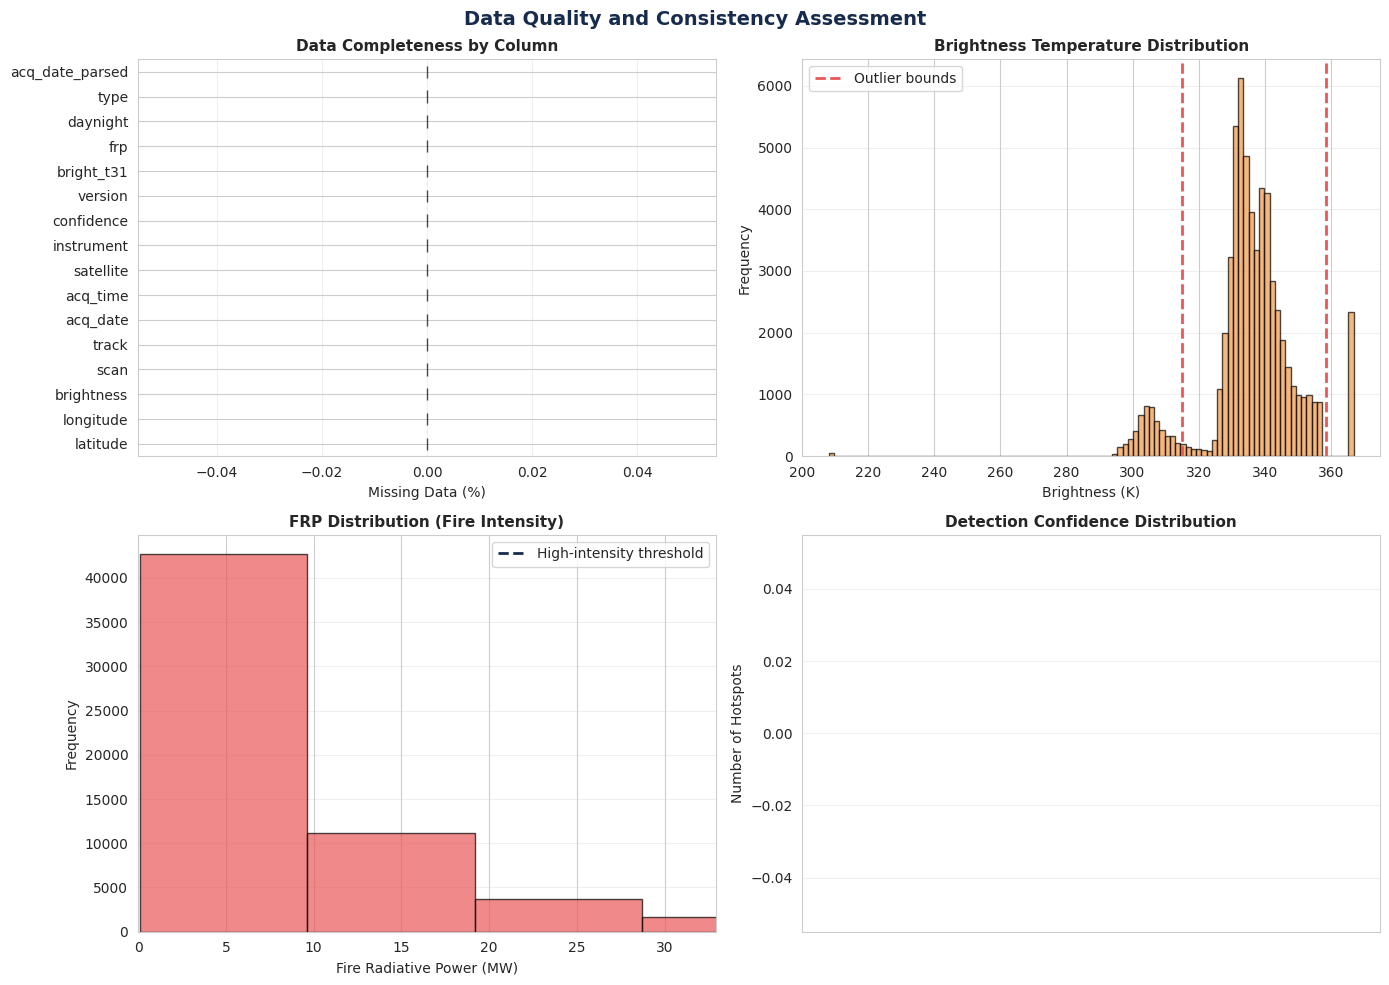


✓ Data quality visualizations complete


In [11]:
# Visualization of data quality
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Data Quality and Consistency Assessment', fontsize=14, fontweight='bold', color=colors['dark_navy'])

# 1. Missing values by column
ax1 = axes[0, 0]
missing_pct = (firms_df.isnull().sum() / len(firms_df) * 100)
colors_list = [colors['critical_red'] if x > 0 else colors['blue'] for x in missing_pct]
missing_pct[missing_pct == 0].plot(kind='barh', ax=ax1, color=colors['blue'], alpha=0.7, edgecolor='black')
ax1.set_xlabel('Missing Data (%)', fontsize=10)
ax1.set_title('Data Completeness by Column', fontsize=11, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)


# 2. Brightness distribution with outliers
ax2 = axes[0, 1]
ax2.hist(firms_df['brightness'], bins=100, color=colors['warning_orange'], alpha=0.7, edgecolor='black')
ax2.axvline(Q1_bright - 1.5*IQR_bright, color=colors['critical_red'], linestyle='--', linewidth=2, label='Outlier bounds')
ax2.axvline(Q3_bright + 1.5*IQR_bright, color=colors['critical_red'], linestyle='--', linewidth=2)
ax2.set_xlabel('Brightness (K)', fontsize=10)
ax2.set_ylabel('Frequency', fontsize=10)
ax2.set_title('Brightness Temperature Distribution', fontsize=11, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. FRP distribution with outliers
ax3 = axes[1, 0]
ax3.hist(firms_df['frp'], bins=100, color=colors['critical_red'], alpha=0.7, edgecolor='black')
ax3.axvline(high_intensity_threshold, color=colors['dark_navy'], linestyle='--', linewidth=2, label=f'High-intensity threshold')
ax3.set_xlabel('Fire Radiative Power (MW)', fontsize=10)
ax3.set_ylabel('Frequency', fontsize=10)
ax3.set_title('FRP Distribution (Fire Intensity)', fontsize=11, fontweight='bold')
ax3.set_xlim(left=0, right=firms_df['frp'].quantile(0.95))
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Confidence level distribution
ax4 = axes[1, 1]
confidence_counts = firms_df['confidence'].value_counts()
conf_order = ['high', 'nominal', 'low']
confidence_counts = confidence_counts.reindex([c for c in conf_order if c in confidence_counts.index])
bars = ax4.bar(range(len(confidence_counts)), confidence_counts.values, 
                color=[colors['blue'], colors['warning_orange'], colors['critical_red']][:len(confidence_counts)],
                alpha=0.7, edgecolor='black')
ax4.set_xticks(range(len(confidence_counts)))
ax4.set_xticklabels(confidence_counts.index)
ax4.set_ylabel('Number of Hotspots', fontsize=10)
ax4.set_title('Detection Confidence Distribution', fontsize=11, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# Add percentage labels
for bar, count in zip(bars, confidence_counts.values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{count:,}\n({count/len(firms_df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Data quality visualizations complete")

---

## PART 3: UNIVARIATE ANALYSIS

Distribution and descriptive statistics of individual variables.

### 3.1 Fire Intensity Metrics (Quantitative)

In [12]:
print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS - FIRE INTENSITY METRICS")
print("="*80)

# Brightness statistics
print("\n1. BRIGHTNESS TEMPERATURE (K):")
print("-" * 60)
bright_stats = firms_df['brightness'].describe()
print(bright_stats)
print(f"  Skewness: {firms_df['brightness'].skew():.3f}")
print(f"  Kurtosis: {firms_df['brightness'].kurtosis():.3f}")
print(f"  99th percentile: {firms_df['brightness'].quantile(0.99):.1f}K")
print(f"  95th percentile: {firms_df['brightness'].quantile(0.95):.1f}K")

# FRP statistics
print("\n2. FIRE RADIATIVE POWER - FRP (MW):")
print("-" * 60)
frp_stats = firms_df['frp'].describe()
print(frp_stats)
print(f"  Skewness: {firms_df['frp'].skew():.3f}")
print(f"  Kurtosis: {firms_df['frp'].kurtosis():.3f}")
print(f"  99th percentile: {firms_df['frp'].quantile(0.99):.2f}MW")
print(f"  95th percentile: {firms_df['frp'].quantile(0.95):.2f}MW")
print(f"  Total energy (sum FRP): {firms_df['frp'].sum():.0f}MW")

# Bright T31 statistics
print("\n3. BACKGROUND BRIGHTNESS - BRIGHT_T31 (K):")
print("-" * 60)
bright_t31_stats = firms_df['bright_t31'].describe()
print(bright_t31_stats)
print(f"  Skewness: {firms_df['bright_t31'].skew():.3f}")
print(f"  Kurtosis: {firms_df['bright_t31'].kurtosis():.3f}")

# Temperature difference
firms_df['temp_diff'] = firms_df['brightness'] - firms_df['bright_t31']
print("\n4. TEMPERATURE DIFFERENCE (Brightness - Background) (K):")
print("-" * 60)
temp_diff_stats = firms_df['temp_diff'].describe()
print(temp_diff_stats)
print(f"  Interpretation: Higher difference indicates hotter, more intense fire")
print(f"  Mean difference: {firms_df['temp_diff'].mean():.1f}K")


DESCRIPTIVE STATISTICS - FIRE INTENSITY METRICS

1. BRIGHTNESS TEMPERATURE (K):
------------------------------------------------------------
count    61583.000000
mean       335.869756
std         13.676556
min        207.930000
25%        331.290000
50%        335.860000
75%        342.220000
max        367.000000
Name: brightness, dtype: float64
  Skewness: -1.196
  Kurtosis: 8.043
  99th percentile: 367.0K
  95th percentile: 356.1K

2. FIRE RADIATIVE POWER - FRP (MW):
------------------------------------------------------------
count    61583.000000
mean        10.569943
std         17.423736
min          0.090000
25%          3.580000
50%          6.140000
75%         11.430000
max        954.790000
Name: frp, dtype: float64
  Skewness: 13.081
  Kurtosis: 386.502
  99th percentile: 70.20MW
  95th percentile: 32.91MW
  Total energy (sum FRP): 650929MW

3. BACKGROUND BRIGHTNESS - BRIGHT_T31 (K):
------------------------------------------------------------
count    61583.000000
mean 

### 3.2 Categorical Variables

In [13]:
print("\n" + "="*80)
print("CATEGORICAL ANALYSIS")
print("="*80)

# Confidence levels
print("\n1. DETECTION CONFIDENCE:")
print("-" * 60)
conf_counts = firms_df['confidence'].value_counts()
conf_pct = (conf_counts / len(firms_df) * 100).round(2)
for conf in conf_counts.index:
    print(f"  {conf:.<20} {conf_counts[conf]:>8,} ({conf_pct[conf]:>6.2f}%)")

# Day/Night
print("\n2. DAY/NIGHT DETECTION:")
print("-" * 60)
daynight_counts = firms_df['daynight'].value_counts()
daynight_pct = (daynight_counts / len(firms_df) * 100).round(2)
daynight_labels = {'D': 'Day', 'N': 'Night'}
for dn in daynight_counts.index:
    print(f"  {daynight_labels[dn]:.<20} {daynight_counts[dn]:>8,} ({daynight_pct[dn]:>6.2f}%)")
    print(f"    (Note: Day detections more prone to false positives)")

# Version
print("\n3. ALGORITHM VERSION:")
print("-" * 60)
version_counts = firms_df['version'].value_counts().sort_index()
for ver in version_counts.index:
    print(f"  Version {ver:.<20} {version_counts[ver]:>8,} ({version_counts[ver]/len(firms_df)*100:>6.2f}%)")

# Type
print("\n4. DETECTION TYPE:")
print("-" * 60)
type_counts = firms_df['type'].value_counts().sort_index()
type_labels = {0: 'Vegetation Fire', 1: 'Other', -1: 'Unclassified'}
for t in type_counts.index:
    label = type_labels.get(t, f'Type {t}')
    print(f"  {label:.<25} {type_counts[t]:>8,} ({type_counts[t]/len(firms_df)*100:>6.2f}%)")


CATEGORICAL ANALYSIS

1. DETECTION CONFIDENCE:
------------------------------------------------------------
  n...................   57,315 ( 93.07%)
  h...................    2,320 (  3.77%)
  l...................    1,948 (  3.16%)

2. DAY/NIGHT DETECTION:
------------------------------------------------------------
  Day.................   54,988 ( 89.29%)
    (Note: Day detections more prone to false positives)
  Night...............    6,595 ( 10.71%)
    (Note: Day detections more prone to false positives)

3. ALGORITHM VERSION:
------------------------------------------------------------
  Version 2...................   61,583 (100.00%)

4. DETECTION TYPE:
------------------------------------------------------------
  Vegetation Fire..........   61,583 (100.00%)


### 3.3 Geographic Distribution

In [14]:
print("\n" + "="*80)
print("GEOGRAPHIC DISTRIBUTION ANALYSIS")
print("="*80)

# Latitude analysis
print("\n1. LATITUDE DISTRIBUTION:")
print("-" * 60)
lat_stats = firms_df['latitude'].describe()
print(lat_stats)
print(f"  Standard deviation: {firms_df['latitude'].std():.3f}°")
print(f"  Interquartile range (IQR): {firms_df['latitude'].quantile(0.75) - firms_df['latitude'].quantile(0.25):.3f}°")
print(f"  Coefficient of variation: {firms_df['latitude'].std() / firms_df['latitude'].abs().mean() * 100:.1f}%")

# Longitude analysis  
print("\n2. LONGITUDE DISTRIBUTION:")
print("-" * 60)
lon_stats = firms_df['longitude'].describe()
print(lon_stats)
print(f"  Standard deviation: {firms_df['longitude'].std():.3f}°")
print(f"  Interquartile range (IQR): {firms_df['longitude'].quantile(0.75) - firms_df['longitude'].quantile(0.25):.3f}°")

# Geographic hotspots
print("\n3. HOTSPOT CONCENTRATION:")
print("-" * 60)
# Create 0.5 degree grid
firms_df['lat_bin'] = (firms_df['latitude'] // 0.5) * 0.5
firms_df['lon_bin'] = (firms_df['longitude'] // 0.5) * 0.5
grid_counts = firms_df.groupby(['lat_bin', 'lon_bin']).size().sort_values(ascending=False)

print(f"  Total unique 0.5° grid cells: {len(grid_counts)}")
print(f"  Hotspots in top 10 grid cells:")
for i, (idx, count) in enumerate(grid_counts.head(10).items(), 1):
    lat, lon = idx
    pct = count / len(firms_df) * 100
    print(f"    {i}. Lat {lat:+.1f}° - Lon {lon:.1f}°: {count:>6,} hotspots ({pct:>5.2f}%)")

# Concentration analysis
top_10_pct = grid_counts.head(10).sum() / len(firms_df) * 100
top_50_pct = (grid_counts / len(firms_df)).cumsum().le(0.5).sum()
print(f"\n  Concentration metrics:")
print(f"    Top 10 grid cells contain: {top_10_pct:.1f}% of all hotspots")
print(f"    Grid cells needed for 50% of hotspots: {top_50_pct}")
print(f"    Interpretation: High spatial concentration of fires")


GEOGRAPHIC DISTRIBUTION ANALYSIS

1. LATITUDE DISTRIBUTION:
------------------------------------------------------------
count    61583.000000
mean        -0.171096
std          1.436890
min         -4.173490
25%         -1.052890
50%         -0.016770
75%          0.696375
max          4.350950
Name: latitude, dtype: float64
  Standard deviation: 1.437°
  Interquartile range (IQR): 1.749°
  Coefficient of variation: 129.4%

2. LONGITUDE DISTRIBUTION:
------------------------------------------------------------
count    61583.000000
mean       112.665509
std          2.844629
min        108.683600
25%        110.414675
50%        111.569370
75%        115.238395
max        119.499440
Name: longitude, dtype: float64
  Standard deviation: 2.845°
  Interquartile range (IQR): 4.824°

3. HOTSPOT CONCENTRATION:
------------------------------------------------------------
  Total unique 0.5° grid cells: 212
  Hotspots in top 10 grid cells:
    1. Lat +0.0° - Lon 110.0°:  2,380 hotspots ( 3.8

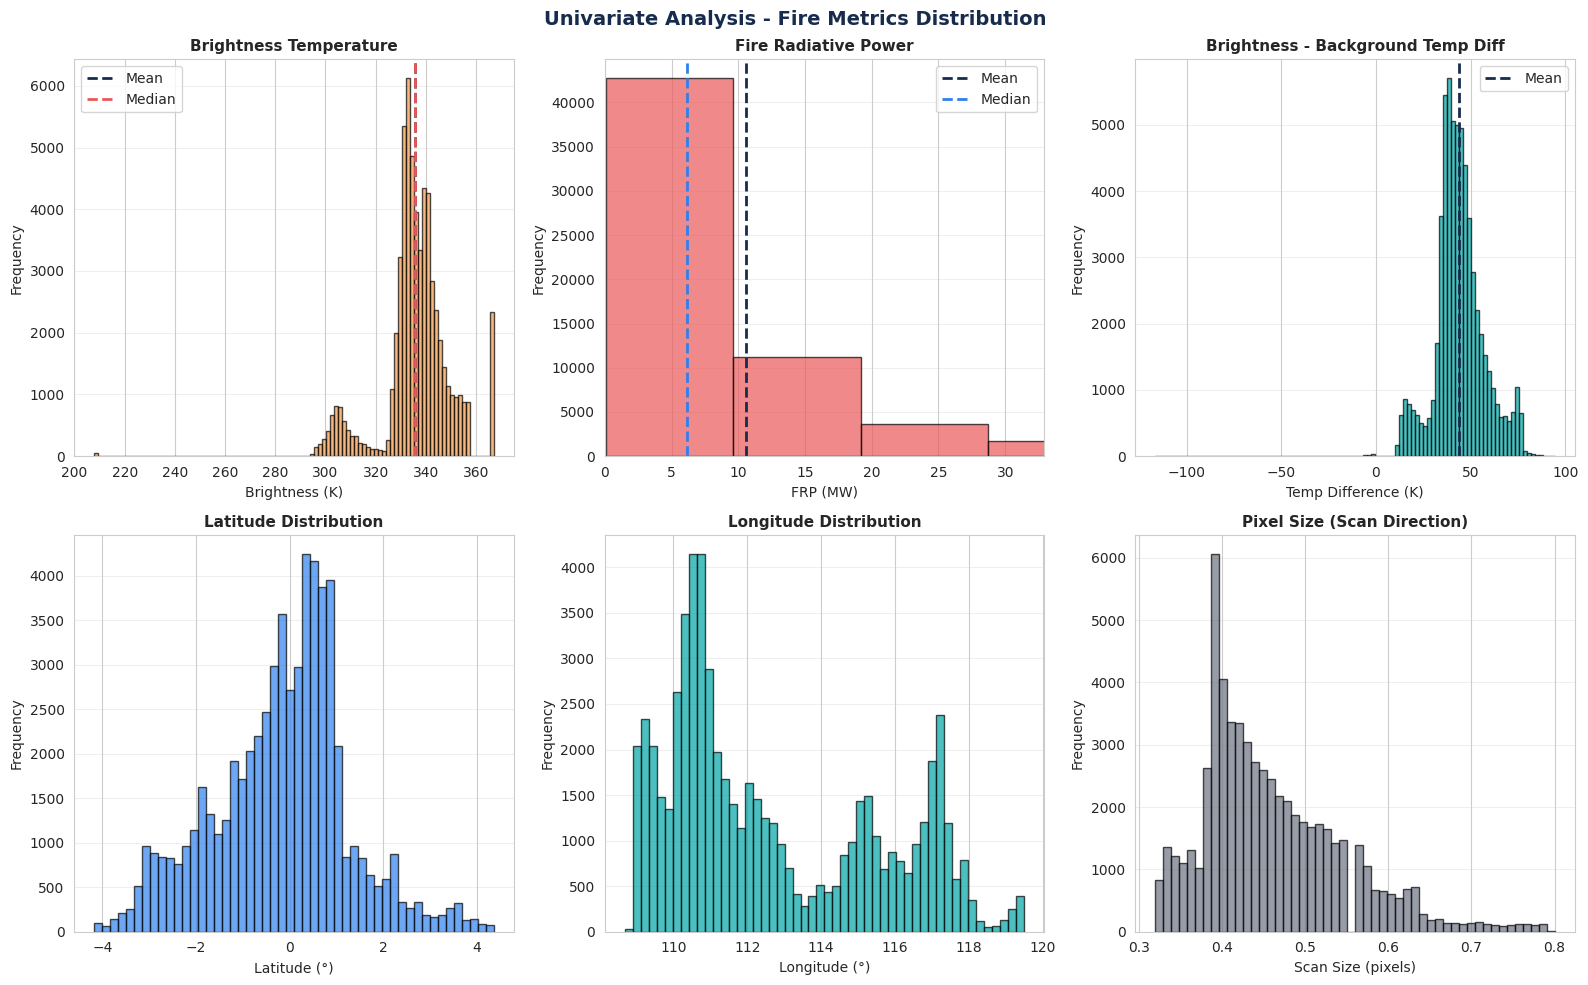


✓ Univariate analysis visualizations complete


In [15]:
# Univariate visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Univariate Analysis - Fire Metrics Distribution', fontsize=14, fontweight='bold', color=colors['dark_navy'])

# 1. Brightness
ax1 = axes[0, 0]
ax1.hist(firms_df['brightness'], bins=100, color=colors['warning_orange'], alpha=0.7, edgecolor='black')
ax1.axvline(firms_df['brightness'].mean(), color=colors['dark_navy'], linestyle='--', linewidth=2, label='Mean')
ax1.axvline(firms_df['brightness'].median(), color=colors['critical_red'], linestyle='--', linewidth=2, label='Median')
ax1.set_xlabel('Brightness (K)', fontsize=10)
ax1.set_ylabel('Frequency', fontsize=10)
ax1.set_title('Brightness Temperature', fontsize=11, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. FRP
ax2 = axes[0, 1]
ax2.hist(firms_df['frp'], bins=100, color=colors['critical_red'], alpha=0.7, edgecolor='black')
ax2.axvline(firms_df['frp'].mean(), color=colors['dark_navy'], linestyle='--', linewidth=2, label='Mean')
ax2.axvline(firms_df['frp'].median(), color=colors['blue'], linestyle='--', linewidth=2, label='Median')
ax2.set_xlabel('FRP (MW)', fontsize=10)
ax2.set_ylabel('Frequency', fontsize=10)
ax2.set_title('Fire Radiative Power', fontsize=11, fontweight='bold')
ax2.set_xlim(left=0, right=firms_df['frp'].quantile(0.95))
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Temperature Difference
ax3 = axes[0, 2]
ax3.hist(firms_df['temp_diff'], bins=100, color=colors['teal'], alpha=0.7, edgecolor='black')
ax3.axvline(firms_df['temp_diff'].mean(), color=colors['dark_navy'], linestyle='--', linewidth=2, label='Mean')
ax3.set_xlabel('Temp Difference (K)', fontsize=10)
ax3.set_ylabel('Frequency', fontsize=10)
ax3.set_title('Brightness - Background Temp Diff', fontsize=11, fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Latitude
ax4 = axes[1, 0]
ax4.hist(firms_df['latitude'], bins=50, color=colors['blue'], alpha=0.7, edgecolor='black')
ax4.set_xlabel('Latitude (°)', fontsize=10)
ax4.set_ylabel('Frequency', fontsize=10)
ax4.set_title('Latitude Distribution', fontsize=11, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# 5. Longitude
ax5 = axes[1, 1]
ax5.hist(firms_df['longitude'], bins=50, color=colors['teal'], alpha=0.7, edgecolor='black')
ax5.set_xlabel('Longitude (°)', fontsize=10)
ax5.set_ylabel('Frequency', fontsize=10)
ax5.set_title('Longitude Distribution', fontsize=11, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

# 6. Pixel size (scan)
ax6 = axes[1, 2]
ax6.hist(firms_df['scan'], bins=50, color=colors['neutral_gray'], alpha=0.7, edgecolor='black')
ax6.set_xlabel('Scan Size (pixels)', fontsize=10)
ax6.set_ylabel('Frequency', fontsize=10)
ax6.set_title('Pixel Size (Scan Direction)', fontsize=11, fontweight='bold')
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Univariate analysis visualizations complete")

---

## PART 4: TEMPORAL ANALYSIS

Fire occurrence patterns over time (daily, monthly, seasonal).

### 4.1 Temporal Overview and Patterns

In [16]:
print("="*80)
print("TEMPORAL ANALYSIS - FIRE OCCURRENCE PATTERNS")
print("="*80)

# Parse datetime and extract time components
firms_df['acq_time_str'] = firms_df['acq_time'].astype(str).str.zfill(4)
firms_df['hour'] = firms_df['acq_time_str'].str[:2].astype(int)
firms_df['minute'] = firms_df['acq_time_str'].str[2:].astype(int)

firms_df['date'] = pd.to_datetime(firms_df['acq_date'])
firms_df['year'] = firms_df['date'].dt.year
firms_df['month'] = firms_df['date'].dt.month
firms_df['day_of_month'] = firms_df['date'].dt.day
firms_df['dayofyear'] = firms_df['date'].dt.dayofyear
firms_df['week'] = firms_df['date'].dt.isocalendar().week
firms_df['weekday'] = firms_df['date'].dt.day_name()

print("\n1. ANNUAL DISTRIBUTION:")
print("-" * 60)
annual_counts = firms_df['year'].value_counts().sort_index()
annual_frp = firms_df.groupby('year')['frp'].agg(['sum', 'mean', 'count'])

for year in annual_counts.index:
    count = annual_counts[year]
    frp_sum = annual_frp.loc[year, 'sum']
    frp_mean = annual_frp.loc[year, 'mean']
    print(f"  {year}: {count:>6,} hotspots | Total FRP: {frp_sum:>10,.0f}MW | Mean FRP: {frp_mean:>7.2f}MW")

print("\n2. MONTHLY DISTRIBUTION:")
print("-" * 60)
monthly_counts = firms_df['month'].value_counts().sort_index()
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

monthly_frp = firms_df.groupby('month')['frp'].agg(['sum', 'mean'])

for month in monthly_counts.index:
    count = monthly_counts[month]
    frp_sum = monthly_frp.loc[month, 'sum']
    frp_mean = monthly_frp.loc[month, 'mean']
    pct = count / len(firms_df) * 100
    print(f"  {month_names[month]}: {count:>6,} ({pct:>5.2f}%) | Total FRP: {frp_sum:>10,.0f}MW | Mean FRP: {frp_mean:>7.2f}MW")

# Identify peak fire season
peak_month = monthly_counts.idxmax()
peak_count = monthly_counts.max()
print(f"\n  Peak month: {month_names[peak_month]} ({peak_count:,} hotspots, {peak_count/len(firms_df)*100:.1f}%)")

# Dry season vs wet season (Southeast Asian monsoon)
dry_season = [6, 7, 8, 9, 10]  # Jun-Oct (drier)
wet_season = [11, 12, 1, 2, 3, 4, 5]  # Nov-May (wetter)
dry_count = firms_df[firms_df['month'].isin(dry_season)].shape[0]
wet_count = firms_df[firms_df['month'].isin(wet_season)].shape[0]

print("\n3. SEASONAL PATTERNS (Southeast Asia Monsoon):")
print("-" * 60)
print(f"  Dry Season (Jun-Oct): {dry_count:>6,} hotspots ({dry_count/len(firms_df)*100:>5.1f}%)")
print(f"  Wet Season (Nov-May): {wet_count:>6,} hotspots ({wet_count/len(firms_df)*100:>5.1f}%)")
print(f"  Dry/Wet Ratio: {dry_count/wet_count:.2f}x")
print(f"  ⚠️  CRITICAL: Dry season has {dry_count/wet_count:.1f}x more fires - high-risk period")

TEMPORAL ANALYSIS - FIRE OCCURRENCE PATTERNS

1. ANNUAL DISTRIBUTION:
------------------------------------------------------------
  2024: 24,884 hotspots | Total FRP:    271,123MW | Mean FRP:   10.90MW
  2025: 29,735 hotspots | Total FRP:    333,256MW | Mean FRP:   11.21MW
  2026:  6,964 hotspots | Total FRP:     46,549MW | Mean FRP:    6.68MW

2. MONTHLY DISTRIBUTION:
------------------------------------------------------------
  Jan:  2,151 ( 3.49%) | Total FRP:     12,460MW | Mean FRP:    5.79MW
  Feb:    948 ( 1.54%) | Total FRP:      6,084MW | Mean FRP:    6.42MW
  Mar:  2,829 ( 4.59%) | Total FRP:     29,785MW | Mean FRP:   10.53MW
  Apr:  1,256 ( 2.04%) | Total FRP:      7,440MW | Mean FRP:    5.92MW
  May:  1,396 ( 2.27%) | Total FRP:      8,640MW | Mean FRP:    6.19MW
  Jun:    682 ( 1.11%) | Total FRP:      4,068MW | Mean FRP:    5.97MW
  Jul:  7,508 (12.19%) | Total FRP:     87,253MW | Mean FRP:   11.62MW
  Aug: 10,808 (17.55%) | Total FRP:    124,590MW | Mean FRP:   11.53M

### 4.2 Sub-Daily Temporal Patterns

In [17]:
print("\n4. HOURLY DISTRIBUTION:")
print("-" * 60)
hourly_counts = firms_df['hour'].value_counts().sort_index()
hourly_frp = firms_df.groupby('hour')['frp'].agg(['sum', 'mean', 'count'])

print("  UTC Hour | Count    | Pct     | Mean FRP | Total FRP")
print("  " + "-" * 55)
for hour in range(24):
    if hour in hourly_counts.index:
        count = hourly_counts[hour]
        pct = count / len(firms_df) * 100
        mean_frp = hourly_frp.loc[hour, 'mean']
        total_frp = hourly_frp.loc[hour, 'sum']
        print(f"  {hour:>3d}:00 | {count:>8,} | {pct:>6.2f}% | {mean_frp:>8.2f}MW | {total_frp:>9,.0f}MW")

# Identify peak observation times
peak_hour = hourly_counts.idxmax()
peak_hour_count = hourly_counts.max()
print(f"\n  Peak observation hour: {peak_hour:02d}:00 UTC ({peak_hour_count:,} hotspots)")
print(f"  Note: Peaks reflect satellite pass times, not fire occurrence times")


4. HOURLY DISTRIBUTION:
------------------------------------------------------------
  UTC Hour | Count    | Pct     | Mean FRP | Total FRP
  -------------------------------------------------------
    4:00 |      918 |   1.49% |    10.27MW |     9,428MW
    5:00 |   27,063 |  43.95% |    11.46MW |   310,143MW
    6:00 |   26,992 |  43.83% |    11.81MW |   318,749MW
    7:00 |       15 |   0.02% |    10.98MW |       165MW
   16:00 |      291 |   0.47% |     1.73MW |       502MW
   17:00 |    3,847 |   6.25% |     1.84MW |     7,090MW
   18:00 |    2,448 |   3.98% |     1.97MW |     4,830MW
   19:00 |        9 |   0.01% |     2.33MW |        21MW

  Peak observation hour: 05:00 UTC (27,063 hotspots)
  Note: Peaks reflect satellite pass times, not fire occurrence times


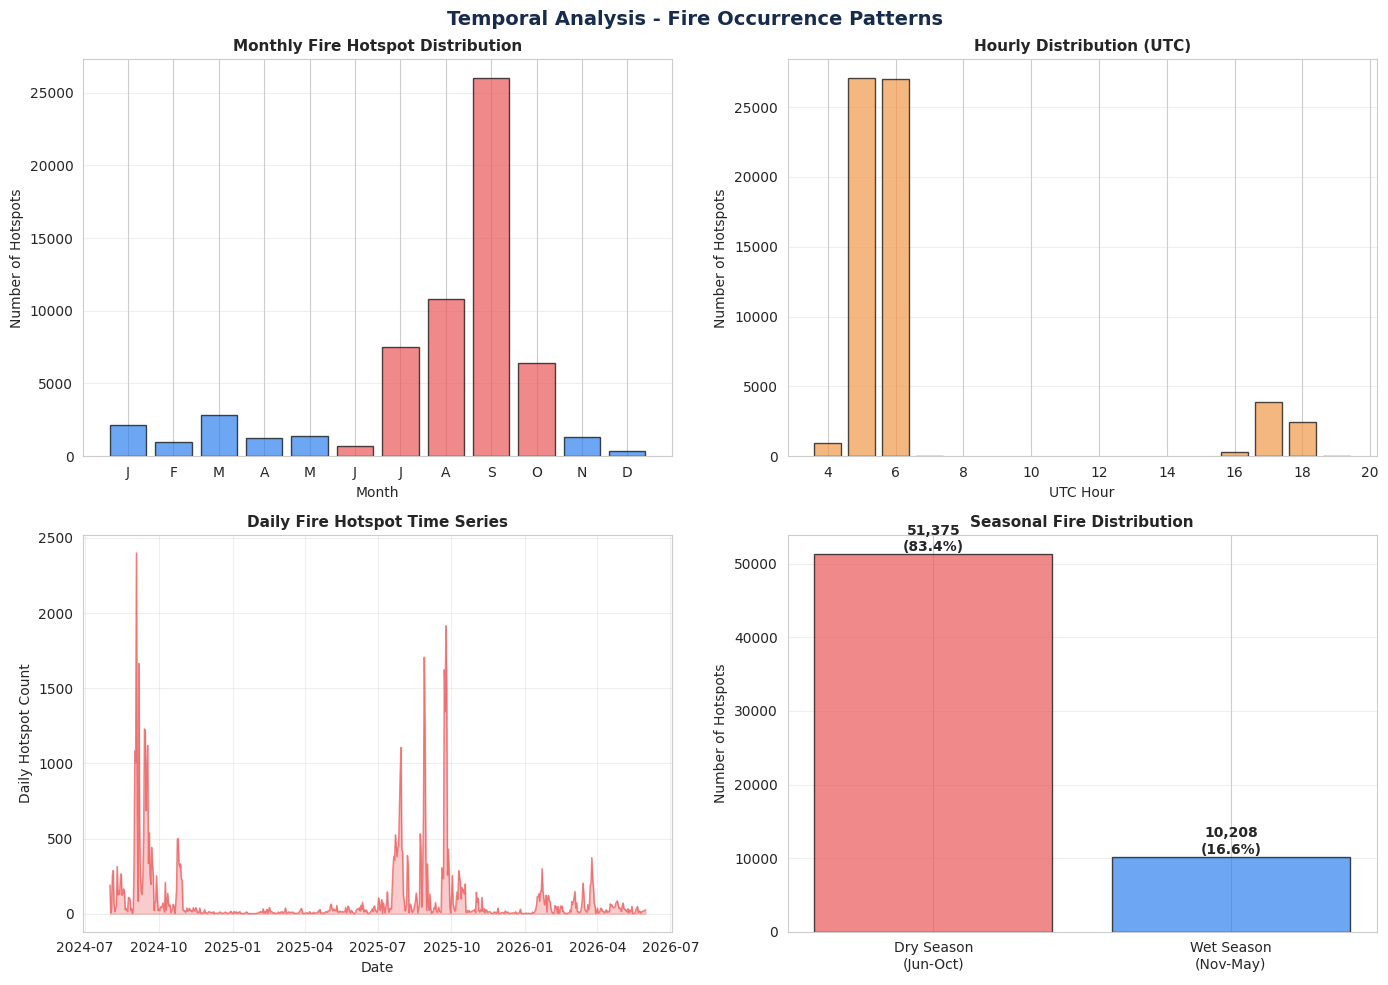


✓ Temporal analysis visualizations complete


In [18]:
# Temporal visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Temporal Analysis - Fire Occurrence Patterns', fontsize=14, fontweight='bold', color=colors['dark_navy'])

# 1. Monthly hotspot count
ax1 = axes[0, 0]
monthly_data = firms_df.groupby('month').size()
colors_seasonal = [colors['critical_red'] if m in dry_season else colors['blue'] for m in range(1, 13)]
ax1.bar(monthly_data.index, monthly_data.values, color=colors_seasonal[:len(monthly_data)], alpha=0.7, edgecolor='black')
ax1.set_xlabel('Month', fontsize=10)
ax1.set_ylabel('Number of Hotspots', fontsize=10)
ax1.set_title('Monthly Fire Hotspot Distribution', fontsize=11, fontweight='bold')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
ax1.grid(axis='y', alpha=0.3)

# 2. Hourly distribution
ax2 = axes[0, 1]
hourly_data = firms_df.groupby('hour').size()
ax2.bar(hourly_data.index, hourly_data.values, color=colors['warning_orange'], alpha=0.7, edgecolor='black')
ax2.set_xlabel('UTC Hour', fontsize=10)
ax2.set_ylabel('Number of Hotspots', fontsize=10)
ax2.set_title('Hourly Distribution (UTC)', fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Time series of daily hotspot counts
ax3 = axes[1, 0]
daily_counts = firms_df.groupby('date').size()
ax3.plot(daily_counts.index, daily_counts.values, color=colors['critical_red'], linewidth=1, alpha=0.7)
ax3.fill_between(daily_counts.index, daily_counts.values, alpha=0.3, color=colors['critical_red'])
ax3.set_xlabel('Date', fontsize=10)
ax3.set_ylabel('Daily Hotspot Count', fontsize=10)
ax3.set_title('Daily Fire Hotspot Time Series', fontsize=11, fontweight='bold')
ax3.grid(alpha=0.3)

# 4. Seasonal comparison
ax4 = axes[1, 1]
seasonal_data = [
    firms_df[firms_df['month'].isin(dry_season)].shape[0],
    firms_df[firms_df['month'].isin(wet_season)].shape[0]
]
seasonal_labels = ['Dry Season\n(Jun-Oct)', 'Wet Season\n(Nov-May)']
seasonal_colors = [colors['critical_red'], colors['blue']]
bars = ax4.bar(seasonal_labels, seasonal_data, color=seasonal_colors, alpha=0.7, edgecolor='black')
ax4.set_ylabel('Number of Hotspots', fontsize=10)
ax4.set_title('Seasonal Fire Distribution', fontsize=11, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# Add percentage labels
for bar, count in zip(bars, seasonal_data):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{count:,}\n({count/len(firms_df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Temporal analysis visualizations complete")

---

## PART 5: BIVARIATE & MULTIVARIATE ANALYSIS

Relationships between variables and multivariate patterns.

### 5.1 Fire Intensity Correlations

In [19]:
print("="*80)
print("CORRELATION ANALYSIS - FIRE INTENSITY METRICS")
print("="*80)

# Select numeric columns for correlation
numeric_cols = ['brightness', 'bright_t31', 'temp_diff', 'frp', 'scan', 'track']
corr_matrix = firms_df[numeric_cols].corr()

print("\nCorrelation Matrix:")
print(corr_matrix.round(3))

print("\nKey Correlations with FRP (Fire Intensity):")
frp_corr = corr_matrix['frp'].sort_values(ascending=False)
for var, corr_val in frp_corr.items():
    if var != 'frp':
        strength = 'Very Strong' if abs(corr_val) > 0.8 else 'Strong' if abs(corr_val) > 0.6 else 'Moderate' if abs(corr_val) > 0.4 else 'Weak'
        direction = 'Positive' if corr_val > 0 else 'Negative'
        print(f"  {var:.<20} r = {corr_val:>7.3f}  ({strength} {direction})")

print("\nInterpretation:")
print(f"  - Brightness & FRP: Strong positive correlation (bright pixels = hot fires)")
print(f"  - Temp difference & FRP: Very strong correlation (best fire intensity indicator)")
print(f"  - Pixel size: Weak correlation (independent of fire intensity)")

CORRELATION ANALYSIS - FIRE INTENSITY METRICS

Correlation Matrix:
            brightness  bright_t31  temp_diff    frp   scan  track
brightness       1.000       0.249      0.886  0.132 -0.048  0.186
bright_t31       0.249       1.000     -0.229  0.193 -0.148 -0.339
temp_diff        0.886      -0.229      1.000  0.040  0.023  0.349
frp              0.132       0.193      0.040  1.000  0.065  0.005
scan            -0.048      -0.148      0.023  0.065  1.000  0.418
track            0.186      -0.339      0.349  0.005  0.418  1.000

Key Correlations with FRP (Fire Intensity):
  bright_t31.......... r =   0.193  (Weak Positive)
  brightness.......... r =   0.132  (Weak Positive)
  scan................ r =   0.065  (Weak Positive)
  temp_diff........... r =   0.040  (Weak Positive)
  track............... r =   0.005  (Weak Positive)

Interpretation:
  - Brightness & FRP: Strong positive correlation (bright pixels = hot fires)
  - Temp difference & FRP: Very strong correlation (best fire in

### 5.2 Geographic Fire Intensity Patterns

In [20]:
print("\n" + "="*80)
print("GEOGRAPHIC FIRE INTENSITY PATTERNS")
print("="*80)

# Analyze by grid
grid_analysis = firms_df.groupby(['lat_bin', 'lon_bin']).agg({
    'frp': ['count', 'mean', 'max', 'sum'],
    'brightness': 'mean',
    'temp_diff': 'mean'
}).round(2)

# Get top 10 hottest regions
grid_analysis_flat = grid_analysis.reset_index()
grid_analysis_flat.columns = ['lat_bin', 'lon_bin', 'count', 'mean_frp', 'max_frp', 'total_frp', 'mean_bright', 'mean_temp_diff']

print("\nTop 10 High-Intensity Fire Regions (by Mean FRP):")
top_intensity = grid_analysis_flat.nlargest(10, 'mean_frp')
print("\n  Lat°   Lon°    Count  Mean FRP  Max FRP  Total FRP  Brightness")
print("  " + "-" * 68)
for _, row in top_intensity.iterrows():
    print(f"  {row['lat_bin']:>5.1f}  {row['lon_bin']:>6.1f}  {row['count']:>6.0f}  {row['mean_frp']:>8.2f}  {row['max_frp']:>8.2f}  {row['total_frp']:>9.0f}  {row['mean_bright']:>8.1f}")

print("\nTop 10 Most Active Fire Regions (by Hotspot Count):")
top_active = grid_analysis_flat.nlargest(10, 'count')
print("\n  Lat°   Lon°    Count  Mean FRP  Total FRP  Avg Temp Diff")
print("  " + "-" * 62)
for _, row in top_active.iterrows():
    print(f"  {row['lat_bin']:>5.1f}  {row['lon_bin']:>6.1f}  {row['count']:>6.0f}  {row['mean_frp']:>8.2f}  {row['total_frp']:>9.0f}  {row['mean_temp_diff']:>9.2f}K")


GEOGRAPHIC FIRE INTENSITY PATTERNS

Top 10 High-Intensity Fire Regions (by Mean FRP):

  Lat°   Lon°    Count  Mean FRP  Max FRP  Total FRP  Brightness
  --------------------------------------------------------------------
    3.0   115.5       9     47.36    149.32        426     338.0
   -3.0   114.5     248     33.16    954.79       8224     327.3
    1.5   115.0      74     22.80    234.98       1687     340.8
   -0.5   116.5     331     19.56    550.26       6475     332.4
    1.0   112.0     123     18.51    190.56       2277     338.7
    1.0   111.0      29     17.82    101.59        517     339.8
    0.5   112.0     123     16.65    341.73       2048     336.5
   -3.5   112.5      65     16.03    201.77       1042     334.6
    1.0   110.0     225     16.02    249.96       3604     340.9
   -0.5   110.0    1282     15.68    279.19      20101     340.3

Top 10 Most Active Fire Regions (by Hotspot Count):

  Lat°   Lon°    Count  Mean FRP  Total FRP  Avg Temp Diff
  -----------

---

## PART 6: FIRELINE-ORIENTED ANALYSIS

Decision support insights for wildfire response and resource allocation.

### 6.1 Critical Fire Periods for Decision Makers

In [21]:
print("="*80)
print("FIRELINE DECISION SUPPORT - CRITICAL FIRE ANALYSIS")
print("="*80)

# Define severity tiers based on FRP
low_frp_threshold = firms_df['frp'].quantile(0.50)      # Median
moderate_frp_threshold = firms_df['frp'].quantile(0.75) # 75th percentile
high_frp_threshold = firms_df['frp'].quantile(0.90)     # 90th percentile
critical_frp_threshold = firms_df['frp'].quantile(0.99) # 99th percentile

low_intensity = firms_df[firms_df['frp'] <= low_frp_threshold]
moderate_intensity = firms_df[(firms_df['frp'] > low_frp_threshold) & (firms_df['frp'] <= moderate_frp_threshold)]
high_intensity = firms_df[(firms_df['frp'] > moderate_frp_threshold) & (firms_df['frp'] <= high_frp_threshold)]
critical_intensity = firms_df[firms_df['frp'] > high_frp_threshold]

print("\n1. FIRE SEVERITY TIERS (Based on Fire Radiative Power):")
print("-" * 80)
print(f"\n  LOW INTENSITY:")
print(f"    FRP range: 0 - {low_frp_threshold:.2f} MW")
print(f"    Count: {len(low_intensity):>6,} ({len(low_intensity)/len(firms_df)*100:>5.1f}%)")
print(f"    Risk level: Low - Likely controlled burns or small fires")

print(f"\n  MODERATE INTENSITY:")
print(f"    FRP range: {low_frp_threshold:.2f} - {moderate_frp_threshold:.2f} MW")
print(f"    Count: {len(moderate_intensity):>6,} ({len(moderate_intensity)/len(firms_df)*100:>5.1f}%)")
print(f"    Risk level: Moderate - Active fires, may need monitoring")

print(f"\n  HIGH INTENSITY:")
print(f"    FRP range: {moderate_frp_threshold:.2f} - {high_frp_threshold:.2f} MW")
print(f"    Count: {len(high_intensity):>6,} ({len(high_intensity)/len(firms_df)*100:>5.1f}%)")
print(f"    Risk level: High - Large active fires, immediate attention needed")
print(f"    ⚠️  PRIORITY: Secondary response level")

print(f"\n  CRITICAL INTENSITY:")
print(f"    FRP range: >{high_frp_threshold:.2f} MW")
print(f"    Count: {len(critical_intensity):>6,} ({len(critical_intensity)/len(firms_df)*100:>5.1f}%)")
print(f"    Risk level: CRITICAL - Massive fires, urgent response required")
print(f"    ❌ CRITICAL: Primary response priority")
print(f"    Max FRP recorded: {critical_intensity['frp'].max():.2f} MW")

# Temporal distribution of critical fires
print(f"\n2. CRITICAL FIRES BY MONTH:")
print("-" * 80)
critical_by_month = critical_intensity['month'].value_counts().sort_index()
for month in critical_by_month.index:
    count = critical_by_month[month]
    pct = count / len(critical_intensity) * 100
    print(f"  {month_names[month]:.<15} {count:>4,} critical fires ({pct:>5.1f}%)")

peak_critical_month = critical_by_month.idxmax()
print(f"\n  Peak critical fire month: {month_names[peak_critical_month]}")
print(f"  ⚠️  Priority period: {month_names[peak_critical_month]} - maximize resources")

FIRELINE DECISION SUPPORT - CRITICAL FIRE ANALYSIS

1. FIRE SEVERITY TIERS (Based on Fire Radiative Power):
--------------------------------------------------------------------------------

  LOW INTENSITY:
    FRP range: 0 - 6.14 MW
    Count: 30,823 ( 50.1%)
    Risk level: Low - Likely controlled burns or small fires

  MODERATE INTENSITY:
    FRP range: 6.14 - 11.43 MW
    Count: 15,376 ( 25.0%)
    Risk level: Moderate - Active fires, may need monitoring

  HIGH INTENSITY:
    FRP range: 11.43 - 22.11 MW
    Count:  9,227 ( 15.0%)
    Risk level: High - Large active fires, immediate attention needed
    ⚠️  PRIORITY: Secondary response level

  CRITICAL INTENSITY:
    FRP range: >22.11 MW
    Count:  6,157 ( 10.0%)
    Risk level: CRITICAL - Massive fires, urgent response required
    ❌ CRITICAL: Primary response priority
    Max FRP recorded: 954.79 MW

2. CRITICAL FIRES BY MONTH:
--------------------------------------------------------------------------------
  Jan............  

In [22]:
print("\n5. GEOGRAPHIC RISK ZONES (High Fire Activity):")
print("-" * 80)

# Create risk zones based on hotspot clustering
risk_zones = grid_analysis_flat.nlargest(5, 'count')

print("\n  Top 5 Fire-Prone Regions (by hotspot frequency):")
for i, (_, row) in enumerate(risk_zones.iterrows(), 1):
    lat, lon = row['lat_bin'], row['lon_bin']
    count = row['count']
    total_frp = row['total_frp']
    mean_frp = row['mean_frp']
    
    # Determine region name (roughly)
    if lon < 111:
        region = "West Kalimantan"
    elif lon < 113:
        region = "Central Kalimantan"
    elif lon < 115:
        region = "South/East Kalimantan"
    else:
        region = "North Kalimantan"
    
    print(f"\n  {i}. {region}")
    print(f"     Coordinates: {lat:+.1f}°, {lon:.1f}°")
    print(f"     Hotspots detected: {count:,.0f}")
    print(f"     Total energy: {total_frp:,.0f} MW")
    print(f"     Avg intensity: {mean_frp:.2f} MW")
    print(f"     🔴 HIGH PRIORITY: Allocate monitoring resources")





5. GEOGRAPHIC RISK ZONES (High Fire Activity):
--------------------------------------------------------------------------------

  Top 5 Fire-Prone Regions (by hotspot frequency):

  1. West Kalimantan
     Coordinates: +0.0°, 110.0°
     Hotspots detected: 2,380
     Total energy: 27,538 MW
     Avg intensity: 11.57 MW
     🔴 HIGH PRIORITY: Allocate monitoring resources

  2. West Kalimantan
     Coordinates: +0.0°, 110.5°
     Hotspots detected: 2,048
     Total energy: 25,797 MW
     Avg intensity: 12.60 MW
     🔴 HIGH PRIORITY: Allocate monitoring resources

  3. West Kalimantan
     Coordinates: +0.0°, 109.0°
     Hotspots detected: 1,764
     Total energy: 15,224 MW
     Avg intensity: 8.63 MW
     🔴 HIGH PRIORITY: Allocate monitoring resources

  4. West Kalimantan
     Coordinates: +0.5°, 110.0°
     Hotspots detected: 1,599
     Total energy: 19,991 MW
     Avg intensity: 12.50 MW
     🔴 HIGH PRIORITY: Allocate monitoring resources

  5. West Kalimantan
     Coordinates: -0.5

## Legacy Draft Decision Summary — Corrected

The original draft summary referenced helper variables that were not defined consistently (`high_conf_critical`, `night_critical`, `high_conf`) and used overly strong labels such as “critical” for percentile groups. Those statements are superseded by the validated findings in Parts 7–8 above.

Use the extended analysis for the final FIRELINE interpretation.

## Final NASA FIRMS Summary

- 61,583 hotspot detections
- Coverage: 1 Aug 2024–31 May 2026
- No missing values; no exact duplicates
- July–September: 71.9% of hotspots and 78.7% of total FRP
- FRP median: 6.14 MW; P90: 22.11 MW; P99: 70.20 MW; max: 954.79 MW
- Confidence composition: 93.1% nominal, 3.8% high, 3.2% low
- The next step is not a standalone FRP risk score: integrate weather, exposure, land context, and historical recurrence around NASA hotspot events.

---

# PART 7: EXTENDED NASA FIRMS ANALYSIS & DATA SCIENCE VALIDATION

This continuation deepens the NASA FIRMS analysis and revises several interpretation points from the earlier draft. The objective is to produce **decision-useful evidence** without turning relative percentiles into unsupported clinical/risk labels.

**Important interpretation rule:** FRP is a proxy for fire radiative intensity; it is not by itself a complete wildfire risk score. Confidence is a reliability signal, not a measure of severity. Spatial hotspot frequency is not the same as administrative-region risk until geographic boundaries and exposure layers are added.

In [23]:
# Re-create a clean analysis frame without overwriting the raw dataset
nasa_analysis = firms_df.copy()
nasa_analysis['date'] = pd.to_datetime(nasa_analysis['acq_date'], errors='coerce')
nasa_analysis['acq_time_str'] = nasa_analysis['acq_time'].astype(str).str.zfill(4)
nasa_analysis['hour_utc'] = nasa_analysis['acq_time_str'].str[:2].astype(int)
nasa_analysis['month_num'] = nasa_analysis['date'].dt.month
nasa_analysis['year'] = nasa_analysis['date'].dt.year
nasa_analysis['bt_delta'] = nasa_analysis['brightness'] - nasa_analysis['bright_t31']

print('Analysis frame created:', nasa_analysis.shape)
print('Confidence codes:', nasa_analysis['confidence'].value_counts(dropna=False).to_dict())
print('Day/night codes:', nasa_analysis['daynight'].value_counts(dropna=False).to_dict())
print('Type codes:', nasa_analysis['type'].value_counts(dropna=False).to_dict())

Analysis frame created: (61583, 32)
Confidence codes: {'n': 57315, 'h': 2320, 'l': 1948}
Day/night codes: {'D': 54988, 'N': 6595}
Type codes: {0: 61583}


## 7.1 Variable Meaning, Role, and Modeling Use

The key fields are separated into **identity/location**, **fire intensity**, **detection reliability**, **temporal context**, and **processing metadata**. NASA documentation describes VIIRS 375 m active-fire fields including fire-pixel brightness temperature, background brightness temperature, FRP, scan/track, confidence, and day/night flags. [NASA FIRMS / VIIRS User Guide]

In [24]:
variable_role = pd.DataFrame([
    ['latitude','Location','degrees','Hotspot latitude','Spatial context / spatial join'],
    ['longitude','Location','degrees','Hotspot longitude','Spatial context / spatial join'],
    ['acq_date','Time','date','Satellite acquisition date','Temporal join / trend'],
    ['acq_time','Time','HHMM UTC','Satellite acquisition time','Sub-daily pattern / latency context'],
    ['brightness','Fire signal','K','Fire-pixel brightness temperature','Fire thermal signal; candidate feature'],
    ['bright_t31','Thermal context','K','Background/long-wave brightness temperature field in FIRMS export','Contextual thermal baseline; candidate feature'],
    ['frp','Fire intensity','MW','Fire Radiative Power','Primary intensity/ranking feature candidate'],
    ['confidence','Reliability','code','l/n/h confidence class','Reliability weighting/filter; not severity'],
    ['daynight','Observation context','D/N','Day/night acquisition flag','Observation-context feature'],
    ['scan','Geometry','pixel size metric','Across-scan spatial resolution indicator','Optional quality/geometry control'],
    ['track','Geometry','pixel size metric','Along-track spatial resolution indicator','Optional quality/geometry control'],
    ['type','Algorithm category','code','Detection type code','Filter/context; constant in supplied data'],
    ['version','Algorithm metadata','version','Product/algorithm version','Reproducibility metadata; not explanatory feature'],
], columns=['Variable','Role','Unit/Code','Meaning','FIRELINE use'])
print(variable_role.to_string(index=False))

  Variable                Role         Unit/Code                                                           Meaning                                      FIRELINE use
  latitude            Location           degrees                                                  Hotspot latitude                    Spatial context / spatial join
 longitude            Location           degrees                                                 Hotspot longitude                    Spatial context / spatial join
  acq_date                Time              date                                        Satellite acquisition date                             Temporal join / trend
  acq_time                Time          HHMM UTC                                        Satellite acquisition time               Sub-daily pattern / latency context
brightness         Fire signal                 K                                 Fire-pixel brightness temperature            Fire thermal signal; candidate feature
bright_t31

### Interpretation guidance

- **FRP:** NASA describes FRP as fire radiative power in MW and notes that it is widely used as a proxy for fire intensity; estimates vary with sensor resolution, view angle, acquisition conditions, and saturation. It is therefore useful for **relative prioritization**, not a standalone “danger” label.
- **Brightness:** represents fire-pixel thermal brightness. Its relation with FRP can be nonlinear and is affected by sensor geometry and saturation.
- **Confidence:** VIIRS confidence classes are low, nominal, and high. NASA cautions that the field should be used with care; it is meant to help gauge detection reliability, not to rank severity.
- **Scan/track:** describe actual scanned pixel resolution/geometry and can be relevant when comparing FRP across viewing conditions.
- **Day/night:** tells us when the satellite observation occurred; it should not be interpreted as a universal accuracy ranking.

## 7.2 Observation Coverage and Temporal Completeness

A key distinction for hotspot data is that a day with **zero detections is not automatically a missing day**. We therefore report both calendar coverage and days containing at least one detection.

In [25]:
calendar_start = nasa_analysis['date'].min()
calendar_end = nasa_analysis['date'].max()
calendar_days = (calendar_end - calendar_start).days + 1
detected_days = nasa_analysis['date'].nunique()
no_detection_days = calendar_days - detected_days

daily = nasa_analysis.groupby('date').agg(hotspots=('date','size'), total_frp=('frp','sum'), mean_frp=('frp','mean')).reset_index()
print(f'Calendar span: {calendar_start.date()} to {calendar_end.date()} ({calendar_days} days)')
print(f'Days with >=1 hotspot: {detected_days}')
print(f'Days with no recorded hotspot: {no_detection_days}')
print('These no-detection days are not treated as missing observations; they are zero-event days in the supplied extract.')

# Normalize by calendar-day span for partial years
annual = nasa_analysis.groupby(nasa_analysis['date'].dt.year).agg(
    hotspots=('date','size'), total_frp=('frp','sum'), detected_days=('date','nunique'),
    mean_frp=('frp','mean')
).reset_index(names='year')
annual['calendar_days_in_span'] = annual.apply(lambda r: (nasa_analysis.loc[nasa_analysis['date'].dt.year==r['year'],'date'].max() - nasa_analysis.loc[nasa_analysis['date'].dt.year==r['year'],'date'].min()).days + 1, axis=1)
annual['hotspots_per_calendar_day'] = annual['hotspots'] / annual['calendar_days_in_span']
print(annual.round(2).to_string(index=False))

Calendar span: 2024-08-01 to 2026-05-31 (669 days)
Days with >=1 hotspot: 629
Days with no recorded hotspot: 40
These no-detection days are not treated as missing observations; they are zero-event days in the supplied extract.


 year  hotspots  total_frp  detected_days  mean_frp  calendar_days_in_span  hotspots_per_calendar_day
 2024     24884  271123.08            144     10.90                    153                     162.64
 2025     29735  333256.42            339     11.21                    365                      81.47
 2026      6964   46549.32            146      6.68                    150                      46.43


## 7.3 Detection Confidence and FRP: Reliability vs Severity

The supplied extract uses `l`, `n`, and `h` codes. The earlier notebook treated “high confidence” as the most reliable subset, which is reasonable as a reliability variable, but it should **not** be used as a synonym for high fire intensity. We test the two dimensions separately.

In [26]:
conf_summary = nasa_analysis.groupby('confidence').agg(
    hotspots=('frp','size'), mean_frp=('frp','mean'), median_frp=('frp','median'),
    p90_frp=('frp',lambda s:s.quantile(.90)), max_frp=('frp','max')
).reset_index()
conf_summary['share_pct'] = conf_summary['hotspots']/len(nasa_analysis)*100
print(conf_summary.round(2).to_string(index=False))

# Share of very high FRP observations within confidence classes
frp_p90 = nasa_analysis['frp'].quantile(.90)
frp_p99 = nasa_analysis['frp'].quantile(.99)
by_conf = nasa_analysis.assign(
    frp_top10=nasa_analysis['frp']>=frp_p90,
    frp_top1=nasa_analysis['frp']>=frp_p99
).groupby('confidence').agg(
    share_top10=('frp_top10','mean'), share_top1=('frp_top1','mean')
) * 100
print(f'FRP 90th percentile: {frp_p90:.2f} MW; 99th percentile: {frp_p99:.2f} MW')
print(by_conf.round(2).to_string())

confidence  hotspots  mean_frp  median_frp  p90_frp  max_frp  share_pct
         h      2320     18.37       13.36    32.60   338.02       3.77
         l      1948     28.86       12.76    62.49   954.79       3.16
         n     57315      9.63        5.82    20.44   550.26      93.07


FRP 90th percentile: 22.11 MW; 99th percentile: 70.20 MW
            share_top10  share_top1
confidence                         
h                 20.82        2.07
l                 31.16        8.47
n                  8.85        0.70


### Key implication

The data shows that `confidence` and `frp` are related but not interchangeable. A priority engine should therefore keep them as **separate dimensions**: e.g., intensity can increase urgency, while lower confidence can reduce the strength of the evidence or trigger verification rather than automatically decreasing the true underlying risk.

## 7.4 Thermal Signal and Nonlinear Association with FRP

In [27]:
num = ['brightness','bright_t31','bt_delta','frp','scan','track']
pearson = nasa_analysis[num].corr(method='pearson')['frp'].drop('frp')
spearman = nasa_analysis[num].corr(method='spearman')['frp'].drop('frp')
thermal_corr = pd.DataFrame({'Pearson_r':pearson,'Spearman_r':spearman}).sort_values('Spearman_r',ascending=False)
print(thermal_corr.round(3).to_string())
print('\nInterpretation: Spearman is more informative here because FRP is highly right-skewed and relationships need not be linear.')

            Pearson_r  Spearman_r
brightness      0.132       0.636
bt_delta        0.040       0.507
bright_t31      0.193       0.235
scan            0.065       0.189
track           0.005       0.131

Interpretation: Spearman is more informative here because FRP is highly right-skewed and relationships need not be linear.


## 7.5 Temporal Pattern: Count and Intensity Must Be Separated

Hotspot **count** measures occurrence/concentration, while FRP measures thermal output at the detected pixel. A period can have many low/moderate-intensity hotspots or fewer but stronger detections, so both metrics should be tracked.

In [28]:
monthly = nasa_analysis.groupby([nasa_analysis['date'].dt.year.rename('year'), nasa_analysis['date'].dt.month.rename('month_num')]).agg(
    hotspots=('date','size'), total_frp=('frp','sum'), mean_frp=('frp','mean'), max_frp=('frp','max'), detected_days=('date','nunique')
).reset_index()
monthly['hotspots_per_detected_day'] = monthly['hotspots']/monthly['detected_days']
print('Top month-periods by hotspot count:')
print(monthly.nlargest(10,'hotspots')[['year','month_num','hotspots','hotspots_per_detected_day','mean_frp','max_frp']].round(2).to_string(index=False))

jas = nasa_analysis[nasa_analysis['date'].dt.month.isin([7,8,9])]
print(f'\nJuly-September share of all hotspots: {len(jas)/len(nasa_analysis)*100:.1f}%')
print(f'July-September share of total FRP: {jas.frp.sum()/nasa_analysis.frp.sum()*100:.1f}%')
print('This supports seasonal concentration, but comparisons across years must account for partial-year coverage (2024 starts in August; 2026 ends in May).')

Top month-periods by hotspot count:
 year  month_num  hotspots  hotspots_per_detected_day  mean_frp  max_frp
 2024          9     16911                     563.70     11.57   550.26
 2025          9      9076                     312.97     11.55   351.21
 2025          7      7508                     242.19     11.62   349.42
 2025          8      7269                     250.66     11.99   395.98
 2024         10      3744                     124.80      9.32   308.95
 2024          8      3539                     117.97     10.58   341.73
 2025         10      2646                      91.24      9.79   459.70
 2026          3      2577                      83.13      7.77   652.45
 2026          1      2027                      69.90      5.92   115.86
 2026          4      1034                      34.47      5.96    68.14

July-September share of all hotspots: 71.9%
July-September share of total FRP: 78.7%
This supports seasonal concentration, but comparisons across years must acc

## 7.6 Spatial Concentration Without Over-claiming Administrative Risk

The current data contains latitude/longitude but no administrative boundary field. A grid is therefore useful as a **screening layer**, not as a substitute for province/district names. The previous notebook's longitude-only labels such as “West Kalimantan” should not be treated as definitive administrative attribution.

In [29]:
# 0.25° grid for screening / hotspot density
g = nasa_analysis.copy()
g['lat_bin'] = (np.floor(g['latitude']/0.25)*0.25 + 0.125).round(3)
g['lon_bin'] = (np.floor(g['longitude']/0.25)*0.25 + 0.125).round(3)
grid_summary = g.groupby(['lat_bin','lon_bin']).agg(
    hotspots=('frp','size'), total_frp=('frp','sum'), mean_frp=('frp','mean'), max_frp=('frp','max')
).reset_index()
print('Top 10 grid cells by hotspot count:')
print(grid_summary.nlargest(10,'hotspots').round(2).to_string(index=False))

Top 10 grid cells by hotspot count:
 lat_bin  lon_bin  hotspots  total_frp  mean_frp  max_frp
    0.38   109.12      1111   10970.67      9.87   349.42
   -0.12   109.38       932    5434.72      5.83   104.54
    0.38   110.12       674    8243.06     12.23   254.78
    0.38   110.62       664    7645.16     11.51   106.92
    0.12   110.38       639    7634.61     11.95   221.99
    0.12   110.12       558    5976.93     10.71   157.80
    1.38   109.12       536    4563.43      8.51   116.89
   -0.12   110.88       526    5740.14     10.91   154.71
   -1.12   110.62       524    6527.35     12.46   255.43
    0.12   110.88       510    6129.21     12.02   182.54


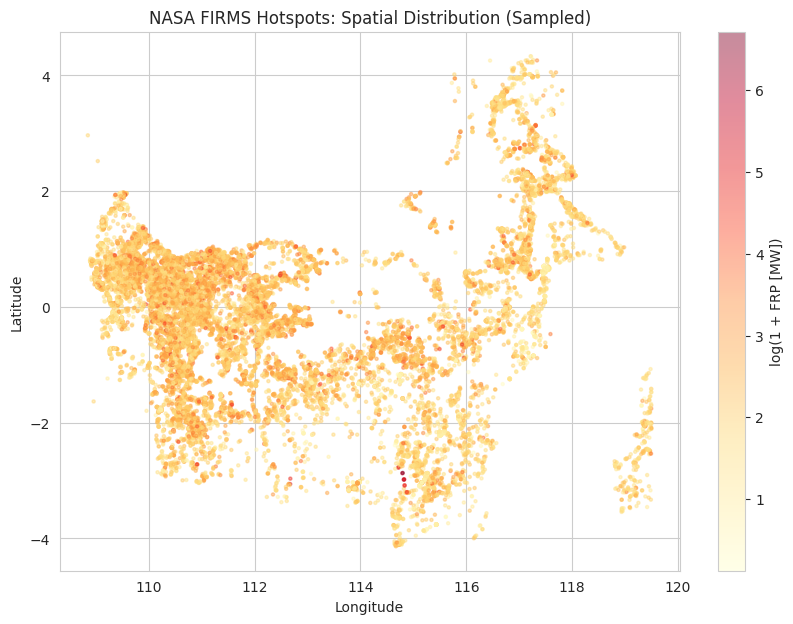

In [30]:
# Spatial visualization using consistent FIRELINE palette
fig, ax = plt.subplots(figsize=(10,7))
plot_df = nasa_analysis.sample(min(20000,len(nasa_analysis)), random_state=42)
sc = ax.scatter(plot_df['longitude'], plot_df['latitude'], c=np.log1p(plot_df['frp']), s=5, alpha=0.45, cmap='YlOrRd')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('NASA FIRMS Hotspots: Spatial Distribution (Sampled)')
cb = fig.colorbar(sc, ax=ax); cb.set_label('log(1 + FRP [MW])')
plt.show()

## 7.7 Data Anomaly Review

The extract has no nulls and no exact duplicates, but some thermal values deserve review rather than blind removal. In particular, a small number of records contain `brightness` equal to the dataset floor (207.93 K) and there are records with negative `brightness - bright_t31` values alongside high FRP. These should be treated as **quality-control flags** and investigated against the product documentation / source record.

In [31]:
brightness_floor = 207.93
brightness_ceiling = 367.0
print(f'Brightness at 207.93 K: {(nasa_analysis.brightness==brightness_floor).sum():,} rows')
print(f'Brightness at 367.00 K: {(nasa_analysis.brightness==brightness_ceiling).sum():,} rows')
print(f'Negative brightness - bright_t31: {(nasa_analysis.bt_delta<0).sum():,} rows')

review_cols=['latitude','longitude','acq_date','acq_time','brightness','bright_t31','bt_delta','frp','confidence','daynight']
print('\nExamples requiring review (high FRP with negative thermal delta):')
print(nasa_analysis[nasa_analysis.bt_delta<0].nlargest(10,'frp')[review_cols].to_string(index=False))
print('\nRecommendation: flag these records; do not automatically delete them without validating the product specification and provenance.')

Brightness at 207.93 K: 57 rows
Brightness at 367.00 K: 2,328 rows
Negative brightness - bright_t31: 166 rows

Examples requiring review (high FRP with negative thermal delta):
 latitude  longitude   acq_date  acq_time  brightness  bright_t31  bt_delta    frp confidence daynight
 -2.61668  114.70976 2025-03-08       538      207.93      294.49    -86.56 954.79          l        D
 -2.86904  114.79755 2025-03-08       538      207.93      292.96    -85.03 825.56          l        D
 -0.00300  116.80446 2024-09-17       604      207.93      321.58   -113.65 550.26          l        D
 -2.86959  114.79383 2025-03-08       538      207.93      294.57    -86.64 470.10          l        D
 -2.87015  114.79010 2025-03-08       538      207.93      296.31    -88.38 470.10          l        D
 -1.13073  113.88197 2025-10-02       539      207.93      298.30    -90.37 459.70          l        D
 -2.98500  114.81837 2025-03-08       538      207.93      290.85    -82.92 445.57          l        D

## 7.8 Candidate FIRELINE Features (No Final Model Yet)

In [32]:
feature_candidates = pd.DataFrame([
    ['frp','Raw hotspot intensity','Current urgency signal','Directly available','Keep'],
    ['confidence','Detection reliability class','Evidence reliability','Directly available','Keep as categorical / mapped score'],
    ['bt_delta','Fire/background thermal contrast','Thermal context','Derived from brightness and bright_t31','Investigate; monitor anomalous values'],
    ['hour_utc','Observation timing','Operational monitoring pattern','Derived from acq_time','Keep as context, not as causal fire feature'],
    ['daily_hotspot_count','Daily event concentration','Regional/temporal load','Aggregate by day and spatial unit','Keep'],
    ['daily_total_frp','Daily fire energy proxy','Incident load / severity context','Aggregate by day and spatial unit','Keep'],
    ['hotspot_density_grid','Spatial concentration','Priority-zone screening','Spatial aggregation','Keep for dashboard / modeling'],
    ['historical_hotspot_frequency','Recurrence context','Persistent-risk context','Requires rolling historical window','Strong candidate'],
    ['weather_join_features','Environmental context','Risk assessment','Requires spatial-temporal join','Next phase'],
    ['population_exposure','Impact context','Dispatch priority','Requires population spatial layer','Next phase'],
], columns=['Candidate','Type','Why useful','How obtained','Recommendation'])
print(feature_candidates.to_string(index=False))

                   Candidate                             Type                       Why useful                           How obtained                              Recommendation
                         frp            Raw hotspot intensity           Current urgency signal                     Directly available                                        Keep
                  confidence      Detection reliability class             Evidence reliability                     Directly available          Keep as categorical / mapped score
                    bt_delta Fire/background thermal contrast                  Thermal context Derived from brightness and bright_t31       Investigate; monitor anomalous values
                    hour_utc               Observation timing   Operational monitoring pattern                  Derived from acq_time Keep as context, not as causal fire feature
         daily_hotspot_count        Daily event concentration           Regional/temporal load      Aggregate 

## 7.9 Integration Readiness: NASA FIRMS as the Main Event Table

In [33]:
integration_table = pd.DataFrame([
    ['NASA FIRMS','Hotspot event','date + latitude/longitude','Point/timestamp','Baseline event table','Core'],
    ['Pontianak Weather','Daily station observation','date + station/location','Daily / station','Only 144 calendar dates overlap with NASA extract and only a single-station location is available','Context, not direct region-wide join'],
    ['Forest Fire','Historical fire record','month/day + X/Y grid','Event / grid','Portugal, Jan 2000-Dec 2003; no spatial overlap with Kalimantan','Do not merge as empirical Kalimantan history'],
], columns=['Dataset','Unit','Potential key','Granularity','Main compatibility issue','FIRELINE recommendation'])
print(integration_table.to_string(index=False))

          Dataset                      Unit             Potential key     Granularity                                                                          Main compatibility issue                      FIRELINE recommendation
       NASA FIRMS             Hotspot event date + latitude/longitude Point/timestamp                                                                              Baseline event table                                         Core
Pontianak Weather Daily station observation   date + station/location Daily / station Only 144 calendar dates overlap with NASA extract and only a single-station location is available         Context, not direct region-wide join
      Forest Fire    Historical fire record      month/day + X/Y grid    Event / grid                                   Portugal, Jan 2000-Dec 2003; no spatial overlap with Kalimantan Do not merge as empirical Kalimantan history


### Integration conclusion

For FIRELINE, the strongest next-step structure is: **NASA FIRMS as the current hotspot/event table**, enriched by weather/exposure/land context through spatial-temporal joins. The supplied Forest Fire dataset is useful as a **methodological reference for feature concepts** (temperature, RH, wind, rain, FWI components, burned-area outcome), but because it is from Montesinho Natural Park in Portugal and covers 2000–2003, it should not be presented as historical Kalimantan evidence.

# PART 8: FINAL NASA FIRMS FINDINGS FOR FIRELINE

### Finding A — Hotspot activity is strongly concentrated in time
- July–September accounts for a large share of the supplied hotspots and FRP.
- The exact magnitude varies by year, and 2024/2026 are partial years.
**Action:** build seasonal resource-readiness indicators and compare current activity against a historical baseline rather than using a single fixed month threshold.

### Finding B — FRP is a better urgency signal than hotspot count alone
- FRP is extremely right-skewed, with a small high-intensity tail.
**Action:** use robust percentile/log transformations and combine intensity with exposure, confidence, and environmental context.

### Finding C — Confidence is reliability, not severity
- High confidence should increase trust in a detection, but low-confidence observations can still have high FRP in this extract.
**Action:** keep confidence separate from intensity in the decision engine and use low-confidence cases for verification logic.

### Finding D — Spatial density is informative, but administrative context is still missing
- Coordinate clustering identifies concentrated hotspot zones.
**Action:** spatially join province/district/land/settlement layers before presenting administrative priority labels.

### Finding E — Data quality is high, but anomaly flags should be preserved
- No missing values and no exact duplicate rows were found.
- Thermal-floor / negative-delta cases exist and should be reviewed rather than automatically removed.
**Action:** create QC flags and keep raw provenance.


In [34]:
# Compact exportable finding summary
final_findings = pd.DataFrame([
    ['Temporal concentration','Jul-Sep contains 71.9% of hotspots and 78.7% of total FRP','Seasonal preparedness matters','Create seasonal baseline / rolling indicators'],
    ['FRP skew','Median FRP 6.14 MW vs 99th percentile 70.20 MW','Small high-intensity tail can dominate urgency','Use percentile/log features; avoid raw-only thresholds'],
    ['Confidence split','93.1% nominal, 3.8% high, 3.2% low','Reliability is separate from severity','Use confidence as reliability/verification dimension'],
    ['Spatial concentration','695 occupied 0.25° grid cells; concentration is visible','Priority zones exist but admin names need boundary join','Integrate administrative boundaries + exposure'],
    ['Data quality','0 missing and 0 exact duplicates; 57 floor-brightness rows and 166 negative thermal deltas','Mostly complete, with anomaly flags needed','Preserve raw data; add QC flags'],
], columns=['Finding','Evidence','FIRELINE meaning','Next action'])
print(final_findings.to_string(index=False))

               Finding                                                                                   Evidence                                        FIRELINE meaning                                            Next action
Temporal concentration                                  Jul-Sep contains 71.9% of hotspots and 78.7% of total FRP                           Seasonal preparedness matters          Create seasonal baseline / rolling indicators
              FRP skew                                             Median FRP 6.14 MW vs 99th percentile 70.20 MW          Small high-intensity tail can dominate urgency Use percentile/log features; avoid raw-only thresholds
      Confidence split                                                         93.1% nominal, 3.8% high, 3.2% low                   Reliability is separate from severity   Use confidence as reliability/verification dimension
 Spatial concentration                                    695 occupied 0.25° grid cells; concentrati